# Chapter 2 experiment harness

This notebook runs **only the experiment the book reports**, the project portion of
Chapter 2. It builds the item-item recommender both ways and reproduces Table 2.1
and Figure 2.2.

It is deliberately not a tour of the whole chapter. Sections 2.2 through 2.5 build
the kernel, the blocked matmul and the mathematics, and those are read in the book
alongside the source files in this directory:

| file | chapter section |
|---|---|
| `matmulkernel.cu` | 2.2.3, the matrix multiply kernel |
| `matmul_launcher.py` | 2.3.1, blocked matmul |
| `distributed_gram_coordinator.py` | 2.3.2, distributed Gram, the exact baseline |
| `demm_launcher.py` | 2.4.2, the DeMM worker (Algorithm 2.1, Gram specialization) |
| `demm_gram_coordinator.py` | 2.4.2, the DeMM Gram coordinator |

Run it top to bottom. On the small dataset it finishes in seconds.

## Environment

Two things worth reporting before any number: which dataset is loaded, and whether
the CUDA kernel path is actually live. A claim about a decentralized system should
never be vague about what ran, so both are printed rather than assumed.

`ml-latest-small` is the default so a first pass is quick. Set `DATASET = "ml-25m"`
for the configuration the book reports, 162,539 users over the 4,000 most-rated
items; it downloads about 250 MB once and takes a few minutes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matmul_launcher, movielens
import distributed_gram_coordinator as exact_gram
import demm_gram_coordinator as demm_gram

DATASET   = "ml-latest-small"      # "ml-25m" for the book's headline run
TOP_ITEMS = None                   # 4000 for ml-25m
N_WORKERS = 8
RANKS     = (16, 32, 64)

DEVICE_IDS = [0] * N_WORKERS       # simulated: N_WORKERS threads on the devices we have

print("CUDA kernel path live:", matmul_launcher.gpu_available())
print("evidence class       : simulated_decentralized")
print("  arithmetic is real; the wide-area network is a byte accounting, not a link")

CUDA kernel path live: True
evidence class       : simulated_decentralized
  arithmetic is real; the wide-area network is a byte accounting, not a link


## 2.1 The project

The interaction matrix `R` has one row per user and one column per item. The
item-item model is the single matrix `G = R^T R`, whose entry `G[i, j]` counts the
users who interacted with both items, and whose contraction runs over **users**.
That is the fact the whole chapter rests on: when users are split across workers,
the multiply splits into local pieces that add back together.

We judge the recommender the honest way. A fifth of each user's likes is held out,
the model is built from the rest, and we measure how many held-out likes land in
the top 50 recommendations: held-out recall@50.

In [2]:
R, titles, info = movielens.load(DATASET, top_items=TOP_ITEMS, holdout=0.2, seed=0)
n_users, n_items = R.shape

print(f"{info['dataset']}: {n_users:,} users x {n_items:,} items, "
      f"{info['n_interactions']:,} training interactions")
print(f"users are the contracted dimension, so they are what gets sharded across "
      f"the {N_WORKERS} workers")

ml-latest-small: 610 users x 1,297 items, 54,318 training interactions
users are the contracted dimension, so they are what gets sharded across the 8 workers


## 2.1.2 The exact baseline: distributed Gram

Each worker takes a block of users, multiplies `R_r^T` by `R_r` with the matrix
multiply kernel, and returns the **full** partial product. The coordinator adds
them, which reproduces the centralized model exactly.

Note what the exchange costs, because it is the reason the rest of the chapter
exists: each worker returns an `n_items` by `n_items` matrix, so the bytes are set
by the size of the catalogue and not by how much data anyone holds. Adding users
increases local work and changes the exchange not at all.

In [3]:
G_exact = exact_gram.distributed_gram(R, device_ids=DEVICE_IDS)

exact_mb = exact_gram.inbound_bytes(n_items, N_WORKERS) / 1e6
raw_mb   = exact_gram.raw_interaction_bytes(info["n_interactions"]) / 1e6

print(f"merged model                     : {G_exact.shape}")
print(f"matches centralized R^T R to     : {np.abs(G_exact - R.T @ R).max():.3g}")
print(f"bytes the coordinator receives   : {exact_mb:,.1f} MB")
print(f"bytes to ship raw interactions   : {raw_mb:,.1f} MB")

merged model                     : (1297, 1297)
matches centralized R^T R to     : 0
bytes the coordinator receives   : 53.8 MB
bytes to ship raw interactions   : 0.4 MB


## 2.1.2 DeMM Gram

Same coordinator, same kernel, different thing returned. Each worker runs
Algorithm 2.1 on its own block and returns a rank-`q` factor `L_r` plus the exact
item-count diagonal, and never forms its partial product at all.

The diagonal is small and load-bearing. Low-rank truncation shrinks the diagonal
that cosine normalization divides by, so it is sent exactly; it costs one number
per item and dropping it costs about a quarter of the recommendation quality at
the scale the book reports.

In [4]:
models = {q: demm_gram.demm_gram(R, device_ids=DEVICE_IDS, q=q) for q in RANKS}

for q, model in models.items():
    mb = demm_gram.inbound_bytes(n_items, q, N_WORKERS) / 1e6
    print(f"q = {q:>2}: {len(model['factors'])} factors of {model['factors'][0].shape}"
          f"  + exact diagonal   ->  {mb:.2f} MB")

q = 16: 8 factors of (1297, 16)  + exact diagonal   ->  0.71 MB
q = 32: 8 factors of (1297, 32)  + exact diagonal   ->  1.37 MB
q = 64: 8 factors of (1297, 64)  + exact diagonal   ->  2.70 MB


## Table 2.1

Both models scored the same way, on the same held-out likes. `Time to assemble`
prices the exchange at a modeled 100 Mbps cross-domain link, which is 12.5
megabytes per second: the local compute is a few milliseconds in every row, so
what separates them is entirely the transfer.

In [5]:
LINK_MB_S = 12.5      # a modeled 100 Mbps cross-domain link

eval_users = np.flatnonzero([len(s) > 0 for s in info["relevant"]])
relevant   = [info["relevant"][u] for u in eval_users]

def score_all(recommender, model):
    "Score every evaluation user, masking the items the model was shown."
    out = np.empty((len(eval_users), n_items), dtype=np.float32)
    for row, u in enumerate(eval_users):
        liked = np.flatnonzero(R[u])
        idx, sc = recommender(model, liked, top_n=n_items)
        full = np.full(n_items, -np.inf, dtype=np.float32)
        full[idx] = sc
        out[row] = full
    return out

rows = []
rec_exact = movielens.recall_at_k(score_all(exact_gram.recommend, G_exact), relevant, 50)
rows.append(("Exact distributed Gram", exact_mb, rec_exact))
rows.append(("Ship raw interactions, build centrally", raw_mb, rec_exact))
for q, model in models.items():
    mb = demm_gram.inbound_bytes(n_items, q, N_WORKERS) / 1e6
    rows.append((f"DeMM summary, q = {q}", mb,
                 movielens.recall_at_k(score_all(demm_gram.recommend, model), relevant, 50)))

# --- table A: the actuals, which are yours and will differ from the book's -------
print("ACTUALS on this machine and this split")
print(f"{'Method':<40}{'WAN MB':>9}{'recall@50':>11}{'assemble':>11}")
for name, mb, rec in rows:
    print(f"{name:<40}{mb:>9.2f}{rec:>11.3f}{mb/LINK_MB_S:>10.2f}s")

# --- table B: the ratios, which are what the book prints -------------------------
def ratio(reference, mine):
    "Fewer bytes than the reference, or more. Never a misleading rounded zero."
    r = reference / mine
    if r >= 10:  return f"{r:.0f}x fewer"
    if r >= 1.0: return f"{r:.1f}x fewer"
    return f"{1/r:.1f}x more"

print()
print("RATIOS  (this is what Table 2.1 in the book reports)")
print(f"{'Method':<40}{'vs exact':>14}{'vs raw':>14}{'quality':>9}")
for name, mb, rec in rows:
    print(f"{name:<40}{ratio(exact_mb, mb):>14}{ratio(raw_mb, mb):>14}{rec/rec_exact:>8.0%}")
print()
print("Assemble time is not a separate column: it is the bytes divided by the link")
print("speed, so the 'vs exact' ratio is also the speedup in time to assemble.")
print()
print("The byte columns are deterministic. They follow from the catalogue size, the")
print("rank and the worker count, so they are arithmetic and you should get them")
print("exactly. The quality column depends on the split, the random probe and the")
print("library, so expect the last digit to move. The shape is what holds: near")
print("parity at rank 32, a few points given up at 16, nothing useful past 64.")


ACTUALS on this machine and this split
Method                                     WAN MB  recall@50   assemble
Exact distributed Gram                      53.83      0.389      4.31s
Ship raw interactions, build centrally       0.43      0.389      0.03s
DeMM summary, q = 16                         0.71      0.361      0.06s
DeMM summary, q = 32                         1.37      0.385      0.11s
DeMM summary, q = 64                         2.70      0.390      0.22s

RATIOS  (this is what Table 2.1 in the book reports)
Method                                        vs exact        vs raw  quality
Exact distributed Gram                      1.0x fewer   123.9x more    100%
Ship raw interactions, build centrally      124x fewer    1.0x fewer    100%
DeMM summary, q = 16                         76x fewer     1.6x more     93%
DeMM summary, q = 32                         39x fewer     3.2x more     99%
DeMM summary, q = 64                         20x fewer     6.2x more    100%

Assemble ti

## Figure 2.2

Quality against bytes. The rank `q` is the single knob: a smaller `q` moves fewer
bytes at a small quality cost, a larger one closes on the exact ceiling.

On this small dataset the raw interactions are cheaper than any fixed-size summary,
so the summary-versus-raw win does not appear. That is not a defect, it is
Proposition 2.3: the summary is fixed in the number of users while the raw data
grows with them, so the crossover needs enough users. Switch `DATASET` to
`ml-25m` and it flips.

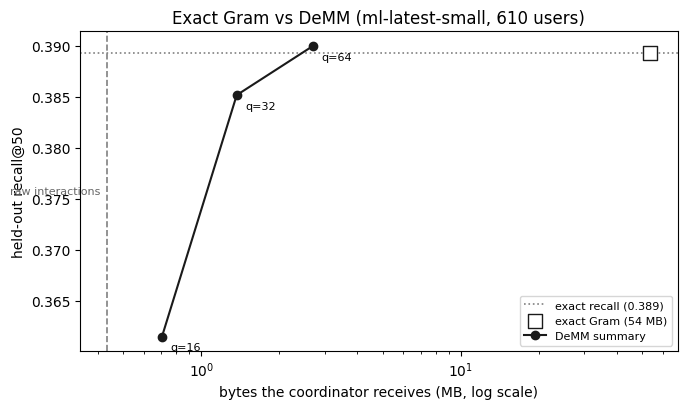

In [6]:
demm_rows = [r for r in rows if r[0].startswith("DeMM")]
xs = [mb for _, mb, _ in demm_rows]
ys = [rec for _, _, rec in demm_rows]

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.axhline(rec_exact, ls=":", color="0.5", lw=1.2, label=f"exact recall ({rec_exact:.3f})")
ax.scatter([exact_mb], [rec_exact], s=90, marker="s", facecolor="white",
           edgecolor="#1a1a1a", zorder=5, label=f"exact Gram ({exact_mb:,.0f} MB)")
ax.plot(xs, ys, "-o", color="#1a1a1a", zorder=4, label="DeMM summary")
for q, x, y in zip(RANKS, xs, ys):
    ax.annotate(f"q={q}", (x, y), textcoords="offset points", xytext=(6, -10), fontsize=8)
ax.axvline(raw_mb, ls="--", color="0.5", lw=1.2)
ax.text(raw_mb, 0.5 * (min(ys) + max(ys)), "raw interactions  ", fontsize=8,
        color="0.4", va="center", ha="right")
ax.set_xscale("log")
ax.set_xlabel("bytes the coordinator receives (MB, log scale)")
ax.set_ylabel("held-out recall@50")
ax.set_title(f"Exact Gram vs DeMM ({info['dataset']}, {n_users:,} users)")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

## What the harness does not show

Two things the book states that this notebook deliberately leaves alone.

The **compressibility boundary**: DeMM's saving is conditional. On data with no
dominant directions the low-rank summary discards real signal and quality drops.
Section 2.5 makes that precise as Proposition 2.2, where the reconstruction error
is exactly the discarded spectrum.

The **merge's tolerance of a missing worker**: because the merge is a sum, a worker
that never reports drops its own term and nothing else. That belongs to the
additive merge rather than to DeMM, since the exact baseline shares it, and
partial participation gets a protocol rather than an observation in Chapter 3.

To see the recommender actually serving, run the app:

```
cd app && ./app_launch.sh
```